<a href="https://colab.research.google.com/github/AkshitaNipane/Machine-Learning-TAE/blob/main/ML_Model_6_(Support_Vector_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_DATASET/customer_feedback_satisfaction.csv')

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   CustomerID  Age  Gender Country  Income  ProductQuality  ServiceQuality  \
0           1   56    Male      UK   83094               5               8   
1           2   69    Male      UK   86860              10               2   
2           3   46  Female     USA   60173               8              10   
3           4   32  Female      UK   73884               7              10   
4           5   60    Male      UK   97546               6               4   

   PurchaseFrequency FeedbackScore LoyaltyLevel  SatisfactionScore  
0                  5           Low       Bronze              100.0  
1                  8        Medium         Gold              100.0  
2                 18        Medium       Silver              100.0  
3                 16           Low         Gold              100.0  
4                 13           Low       Bronze               82.0  


In [ ]:

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:

def svr_model(split_ratio):
    print(f"\n===== SVR ({int(split_ratio*100)}:{int((1-split_ratio)*100)}) =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=(1-split_ratio), random_state=42
    )

    model = SVR(kernel='rbf')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    result_table = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred
    })

    print("\nMSE:", mse)
    print("R2 Score:", r2)

    print("\nOutput Table:")
    print(result_table.head(10))

    return mse, r2, result_table

In [ ]:
svr_mse_80, svr_r2_80, svr_table_80 = svr_model(0.8)


===== SVR (80:19) =====

MSE: 60.95311085184138
R2 Score: 0.782462010427202

Output Table:
   Actual   Predicted
0   88.38   77.434341
1  100.00  100.551441
2  100.00   99.915119
3   84.96   80.209598
4  100.00   99.501964
5   79.28   73.145050
6   82.56   75.365956
7   82.63   98.675999
8   67.36   68.562291
9   89.26   87.280018


In [ ]:
svr_mse_70, svr_r2_70, svr_table_70 = svr_model(0.7)


===== SVR (70:30) =====

MSE: 61.768771658211705
R2 Score: 0.7811570806802277

Output Table:
   Actual   Predicted
0   88.38   77.518500
1  100.00  100.510922
2  100.00   99.944260
3   84.96   80.333507
4  100.00   99.608084
5   79.28   73.293403
6   82.56   75.407099
7   82.63   98.599631
8   67.36   68.998970
9   89.26   86.802706


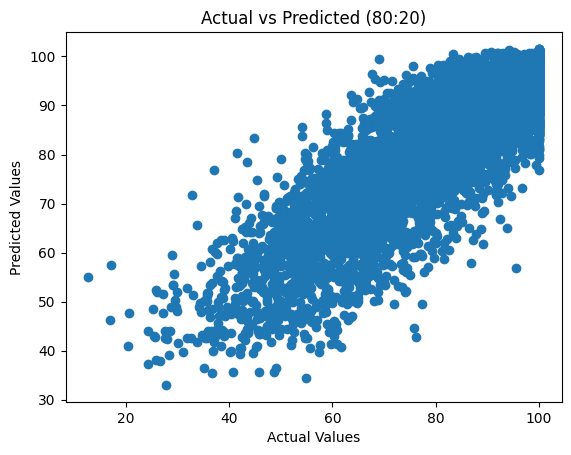

In [ ]:
plt.figure()

plt.scatter(svr_table_80['Actual'], svr_table_80['Predicted'])
plt.title("Actual vs Predicted (80:20)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVR(), param_grid, cv=3)

grid.fit(X_scaled, y)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [10]:
#Error Comparison Table
svr_summary = pd.DataFrame({
    'Split': ['80:20', '70:30'],
    'MSE': [svr_mse_80, svr_mse_70],
    'R2 Score': [svr_r2_80, svr_r2_70]
})

print("\nFinal SVR Summary Table:")
print(svr_summary)


Final SVR Summary Table:
   Split        MSE  R2 Score
0  80:20  60.953111  0.782462
1  70:30  61.768772  0.781157


In [13]:
from sklearn.model_selection import cross_val_score

model = SVR(kernel='rbf')

scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Mean R2 Score:", scores.mean())

Cross Validation Scores: [0.76320225 0.78044274 0.78282321 0.78968457 0.77091774]
Mean R2 Score: 0.7774141014400751


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = SVR()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.7891415989597512
Test R2: 0.782462010427202
